<a href="https://colab.research.google.com/github/sudipta-on/Qiskit_v2_HandsOn/blob/main/Trotterization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="
font-family:'Times New Roman', Times, serif;
padding:24px;
border-radius:14px;
background: linear-gradient(135deg,#f5f7ff,#e8f0ff);
border:2px solid #cfd9ff;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
">

<p style="
font-size:40px;
text-align:center;
font-weight:bold;
color:#b30000;
margin-bottom:6px;
letter-spacing:0.5px;">
Quantum Time Evolution using Qiskit
</p>

<p style="
font-size:22px;
text-align:center;
color:#333;
margin-top:4px;">
Commuting vs Non-Commuting Hamiltonians (Ising & TFIM)
</p>

<hr style="border:1px solid #c9d6ff; margin:16px 0;">

<p style="
font-size:19px;
color:#0a3d91;
text-align:left;">
📘 <b>Course:</b> Quantum Mechanics and Quantum Computation (CD61001)
</p>
<!--
<p style="
font-size:18px;
color:#444;
text-align:left;">
👨‍🏫 <b>Instructor:</b> Sudipta Majumder
</p> -->

<p style="
font-size:17px;
color:#444;
text-align:right;
margin-top:10px;">
🚀 Hybrid Quantum-Classical Algorithm for Ground State Problems
</p>

</div>

<div style="
background:linear-gradient(90deg,#c5dcf5,#8fbce6);
padding:12px 20px;
border-radius:8px;
margin-top:12px;
margin-bottom:12px;
border:1px solid #6fa8dc;">

<h2 style="color:#0b3c6f; margin:0; font-family:'Times New Roman', serif;">
💻 Chapter 1 | Theoretical Overview
</h2>

</div>

<div style="font-family:'Times New Roman'; line-height:1.6; font-size:16px; ">

<p style="text-align:justify;">
The dynamics of a closed quantum system are governed by the time-dependent Schrödinger equation:
</p>

$$ i \frac{d}{dt} |\psi(t)\rangle = H |\psi(t)\rangle $$

<p style="text-align:justify;">
For a time-independent Hamiltonian, the solution is given by the unitary time evolution operator:
</p>

$$ |\psi(t)\rangle = U(t)|\psi(0)\rangle, \quad U(t) = e^{-iHt} $$

<p style="text-align:justify;">
The central objective of digital quantum simulation is to efficiently implement $U(t)$ using quantum gates.
</p>

<h3 style="color:blue; font-weight:bold;">1. Commuting Hamiltonians</h3>

<p style="text-align:justify;">
If the Hamiltonian decomposes as $H = \sum_i H_i$ with $[H_i, H_j] = 0$, then:
</p>

$$ e^{-iHt} = \prod_i e^{-iH_i t} $$

<p style="text-align:justify;">
This allows exact implementation without approximation. For example, the two-qubit Ising interaction: $ H = J Z_1 Z_2 $
</p>

<p style="text-align:justify;">
leads to:
</p>

$$ U(t) = e^{-iJt Z_1 Z_2} $$

<p style="text-align:justify;">
which can be directly realized using the Qiskit gate:
</p>

$$ RZZ(\theta) = e^{-i \theta Z \otimes Z / 2}, \quad \theta = 2Jt $$

<p style="text-align:justify;">
Such systems exhibit phase evolution without state mixing, enabling efficient simulation.
</p>

<h3 style="color:blue; font-weight:bold;">2. Non-Commuting Hamiltonians</h3>

<p style="text-align:justify;">
For systems such as the transverse-field Ising model:
</p>

$$ H = H_Z + H_X = J Z_1 Z_2 + h (X_1 + X_2) $$

<p style="text-align:justify;">
the non-commutativity $[H_Z, H_X] \neq 0$ prevents factorization:
</p>

$$ e^{-i(H_Z + H_X)t} \neq e^{-iH_Z t} e^{-iH_X t} $$

<p style="text-align:justify;">
This leads to non-trivial dynamics involving state transitions and entanglement generation.
</p>

<h4 style="color:green; font-weight:bold;">Trotter–Suzuki Decomposition</h4>

<p style="text-align:justify;">
To approximate the evolution, one employs Trotterization with $\Delta t = t/n$:
</p>

<h4 style="color:blue; font-weight:bold;">First-Order (Lie–Trotter)</h4>

$$ U(t) \approx \left(e^{-iH_Z \Delta t} e^{-iH_X \Delta t}\right)^n $$

<p style="text-align:justify;">
Error scales as $O(t^2/n)$, arising from the leading commutator term via the Baker–Campbell–Hausdorff expansion.
</p>

<h4 style="color:blue; font-weight:bold;">Second-Order (Suzuki)</h4>

$$ U(t) \approx \left(e^{-iH_Z \frac{\Delta t}{2}} \, e^{-iH_X \Delta t} \, e^{-iH_Z \frac{\Delta t}{2}}\right)^n $$

<p style="text-align:justify;">
This symmetric construction cancels first-order error terms, yielding improved accuracy with error scaling: $ O(t^3/n^2) $
</p>



<h4>NOTE:</h4>

<ul>
<li>Higher-order schemes improve accuracy</li>
<li>However, circuit depth increases proportionally</li>
<li>This introduces greater susceptibility to noise on NISQ devices</li>
</ul>

</div>

<div style="
background:linear-gradient(90deg,#c5dcf5,#8fbce6);
padding:12px 20px;
border-radius:8px;
margin-top:12px;
margin-bottom:12px;
border:1px solid #6fa8dc;">

<h2 style="color:#0b3c6f; margin:0; font-family:'Times New Roman', serif;">
💻 Chapter 2 | Qiskit Implementation
</h2>

</div>

<a id="setup"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">Installation and Imports
</h2>
Run the below code to install required packages

In [ ]:
!pip install qiskit qiskit_aer qiskit_algorithms qiskit_ibm_runtime pylatexenc -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

from qiskit.primitives import StatevectorEstimator

from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter

<h3 style="color:blue; font-weight:bold; font-family:'Times New Roman';">
Manual Construction of Time Evolution Circuits
</h3>

In [ ]:
# Helping Function
def compute_expectation(state, observable):
    return np.real(state.expectation_value(observable))

# Commutating Hamiltonian Evolution
def ising_evolution(J, t):
    qc = QuantumCircuit(2)
    qc.h([0,1]) # initial state
    qc.rzz(2 * J * t, 0, 1)
    return qc

# Non-Commutating Hamiltonian Evolution
def tfim_trotter(J, h, t, n_steps):
    qc = QuantumCircuit(2)
    qc.h([0,1]) # initial state
    dt = t / n_steps
    for _ in range(n_steps):
        qc.rzz(2 * J * dt, 0, 1)
        qc.rx(2 * h * dt, 0)
        qc.rx(2 * h * dt, 1)

    return qc

<div style="font-family:'Times New Roman'; line-height:1.7; font-size:16px;">

<h3 style="color:green;">Time Evolution of Physical Observables</h3>

<p>
We now compute expectation values of relevant observables as functions of time:
</p>

<ul>
<li>$\langle \sum_{i,j}Z_iZ_j\rangle \rightarrow $ spin correlation</li>
<li>$\langle \sum_i Z_i \rangle \rightarrow$ total magnetization</li>
<li>$\langle \sum_i X_i \rangle \rightarrow$ transverse magnetization</li>
</ul>

</div>

In [ ]:
# Observables
obs_zz   = SparsePauliOp.from_list([("ZZ", 1)])             # spin correlation
obs_sumz = SparsePauliOp.from_list([("ZI", 1), ("IZ", 1)])  # total magnetization
obs_x1   = SparsePauliOp.from_list([("XI", 1)])             # transverse magnetization

observables = {
    "ZiZj": obs_zz,
    "Zi": obs_sumz,
    "Xi": obs_x1
}

In [ ]:
def property_evolution(times, evolution_func, observables, **kwargs):
    """
    Compute time evolution of observables
    """
    results = {key: [] for key in observables}

    for t in times:
        qc = evolution_func(t=t, **kwargs)
        state = Statevector.from_instruction(qc)

        for name, obs in observables.items():
            val = compute_expectation(state, obs)
            results[name].append(val)

    return results

In [ ]:
times = np.linspace(0, 10, 50)

# Ising (commuting)
ising_results = property_evolution(times, ising_evolution, observables, J=1.0)

# TFIM (non-commuting)
tfim_results = property_evolution(times, tfim_trotter, observables, J=1.0, h=0.8, n_steps=20)

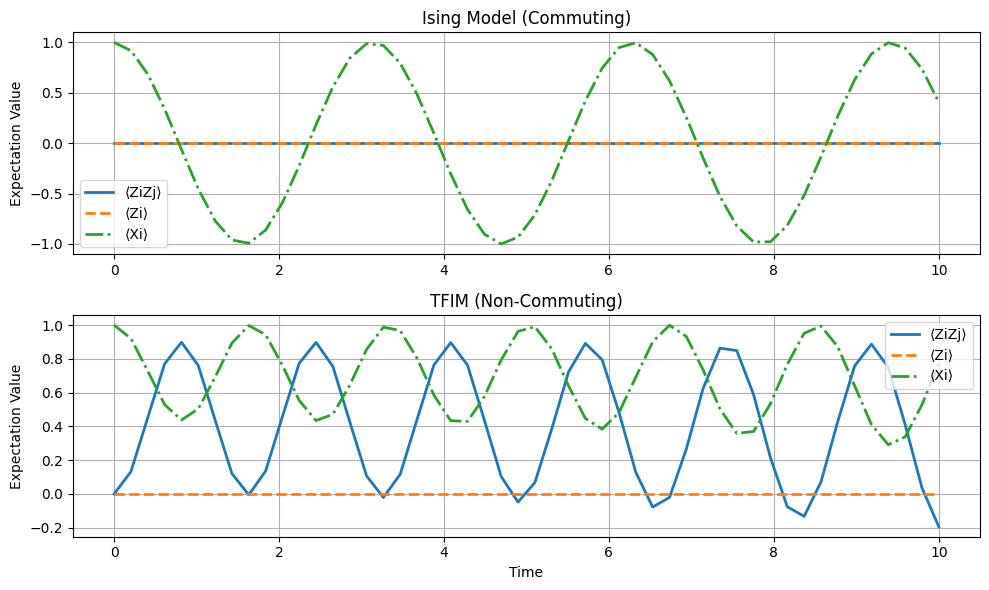

In [ ]:
plt.figure(figsize=(10,6))

# Define linestyles for each observable
linestyles = {
    "ZiZj": "-",
    "Zi": "--",
    "Xi": "-."
}

# Ising
plt.subplot(2,1,1)
for key, vals in ising_results.items():
    plt.plot(times, vals,linestyle=linestyles.get(key, "-"),linewidth=2,label=f"⟨{key}⟩")

plt.title("Ising Model (Commuting)")
plt.ylabel("Expectation Value")
plt.legend()
plt.grid()

# TFIM
plt.subplot(2,1,2)
for key, vals in tfim_results.items():
    plt.plot(times, vals,linestyle=linestyles.get(key, "-"),linewidth=2,label=f"⟨{key}⟩")

plt.title("TFIM (Non-Commuting)")
plt.xlabel("Time")
plt.ylabel("Expectation Value")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

<h3 style="color:blue; font-weight:bold; font-family:'Times New Roman';">
Time Evolution using Built-in Qiskit Algorithms (Trotterization)
</h3>

In [ ]:
# To generalize the problem Hamiltonian
def get_hamiltonian(L, J, h):
    ZZ_tuples = [("ZZ", [i, i + 1], -J) for i in range(0, L - 1)]
    Z_tuples = [("Z", [i], -h ) for i in range(0, L)]
    X_tuples = [("X", [i], -h ) for i in range(0, L)]

    hamiltonian = SparsePauliOp.from_sparse_list([*ZZ_tuples, *Z_tuples, *X_tuples], num_qubits=L)
    return hamiltonian.simplify()

H = get_hamiltonian(L=2, J=0.2, h=1.0)
print(H)

SparsePauliOp(['ZZ', 'IZ', 'ZI', 'IX', 'XI'],
              coeffs=[-0.2+0.j, -1. +0.j, -1. +0.j, -1. +0.j, -1. +0.j])


In [ ]:
from qiskit_algorithms import TimeEvolutionProblem, TrotterQRTE

final_time = 1.6

initial_state = Statevector.from_label("10")

problem = TimeEvolutionProblem(H, initial_state=initial_state, time=final_time)
trotter = TrotterQRTE()
result = trotter.evolve(problem)

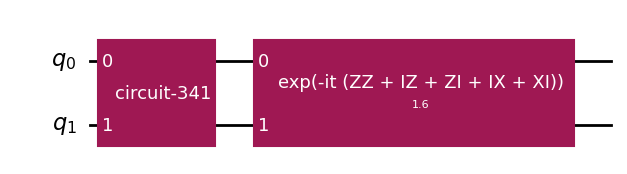

In [ ]:
result.evolved_state.draw("mpl")

In [ ]:
statevector = Statevector(result.evolved_state)
statevector

Statevector([-0.20818179-0.34171085j, -0.27830678+0.19378111j,
              0.67092864-0.12078545j,  0.37643954-0.34416154j],
            dims=(2, 2))


/Users/sudiptamajumder/.pyenv/versions/3.11.8/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/sudiptamajumder/.pyenv/versions/3.11.8/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [ ]:
L=4
H = get_hamiltonian(L=L, J=0.2, h=1.0)
print(H)

SparsePauliOp(['IIZZ', 'IZZI', 'ZZII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIIX', 'IIXI', 'IXII', 'XIII'],
              coeffs=[-0.2+0.j, -0.2+0.j, -0.2+0.j, -1. +0.j, -1. +0.j, -1. +0.j, -1. +0.j,
 -1. +0.j, -1. +0.j, -1. +0.j, -1. +0.j])


In [ ]:
num_timesteps = 60
trotter = TrotterQRTE(num_timesteps=num_timesteps, estimator=StatevectorEstimator())

magnetization_op = SparsePauliOp.from_sparse_list([("Z", [i], 1.0) for i in range(0, L)], num_qubits=L)
correlation_op = SparsePauliOp.from_sparse_list([("ZZ", [i, i + 1], 1.0) for i in range(0, L - 1)], num_qubits=L) / (L - 1)

final_time = 30.0
initial_state = Statevector.from_label("0011")
problem = TimeEvolutionProblem(H, initial_state=initial_state, time=final_time, aux_operators=[H, magnetization_op, correlation_op],truncation_threshold=1e-10)

result = trotter.evolve(problem)

In [ ]:
observables = np.array(np.array(result.observables)[:, :, 0])
observables.shape

(61, 3)

Text(0.5, 0.98, 'Observable evolution')

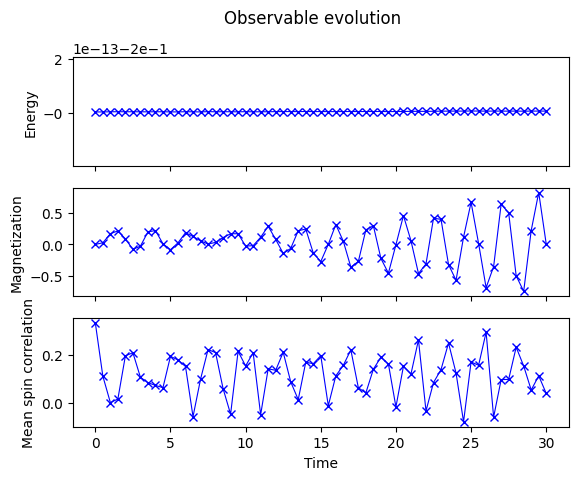

In [ ]:
fig, axes = plt.subplots(3, sharex=True)
times = np.linspace(0, final_time, num_timesteps + 1)  # includes initial state

axes[0].plot(times, observables[:, 0], 'bx-',label="First order",  lw=0.8)
axes[1].plot(times, observables[:, 1], 'bx-', label="First order", lw=0.8)
axes[2].plot(times, observables[:, 2], 'bx-', label="First order", lw=0.8)

axes[0].set_ylabel("Energy")
axes[1].set_ylabel("Magnetization")
axes[2].set_ylabel("Mean spin correlation")
axes[2].set_xlabel("Time")
fig.suptitle("Observable evolution")

<h3 style="color:blue; font-weight:bold; font-family:'Times New Roman';">
Comparing with Exact Time Evolution using SciPy</h3>

In [ ]:
import scipy as sc
H_array = H.to_matrix()

exact_times = np.linspace(0, final_time, 101)

# We compute the exact evolution using the exp
exact_evolution = [initial_state.evolve(sc.linalg.expm(-1j * time * H_array)) for time in exact_times]

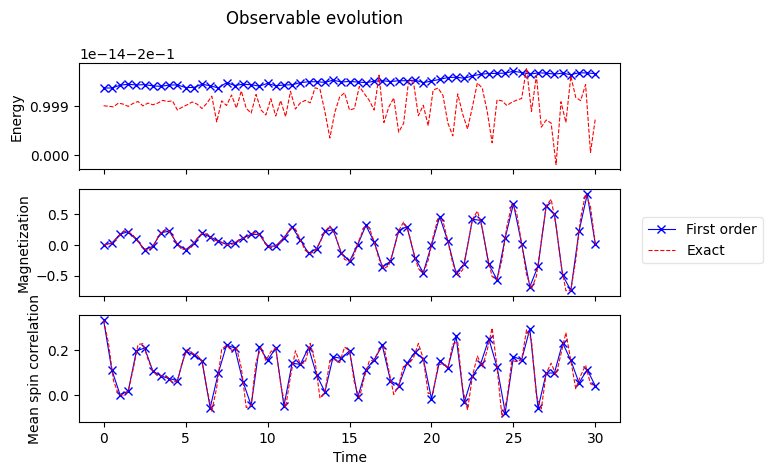

In [ ]:
exact_energy = np.real([sv.expectation_value(H) for sv in exact_evolution])
exact_magnetization = np.real([sv.expectation_value(magnetization_op) for sv in exact_evolution])
exact_correlation = np.real([sv.expectation_value(correlation_op) for sv in exact_evolution])


axes[0].plot(exact_times, exact_energy, 'r--',label="Exact",  lw=0.8)
axes[1].plot(exact_times, exact_magnetization, 'r--', label="Exact", lw=0.8)
axes[2].plot(exact_times, exact_correlation, 'r--', label="Exact", lw=0.8)


# Select the labels of only the first axis
legend = fig.legend(
    *axes[0].get_legend_handles_labels(),
    bbox_to_anchor=(1.0, 0.5),
    loc="center left",
    framealpha=0.5,
)
fig.tight_layout()
fig

In [ ]:
initial_state = Statevector.from_label("0011")

trotter = TrotterQRTE(SuzukiTrotter(order=2), num_timesteps=num_timesteps, estimator=StatevectorEstimator())
problem = TimeEvolutionProblem(H, initial_state=initial_state, time=final_time, aux_operators=[H, magnetization_op, correlation_op])

result = trotter.evolve(problem)

observables_order2 = np.array(np.array(result.observables)[:, :, 0], dtype=np.float64)
# result.evolved_state.draw("mpl")

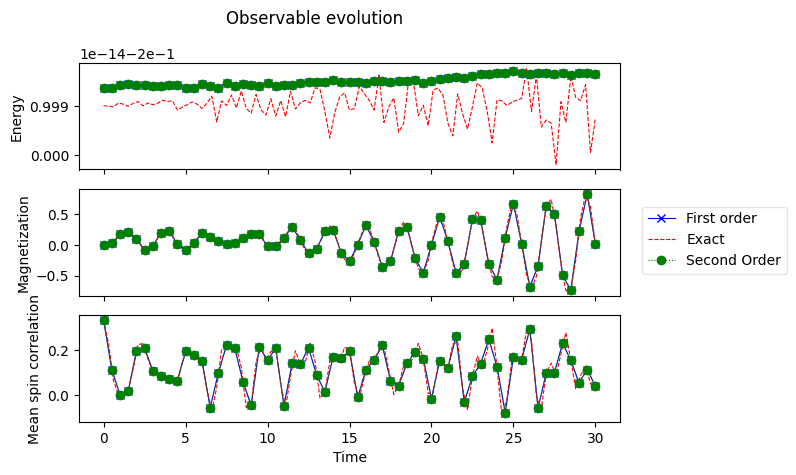

In [ ]:
axes[0].plot(times, observables_order2[:, 0], 'go:',label="Second Order", lw=0.8)
axes[1].plot(times, observables_order2[:, 1], 'go:',label="Second Order", lw=0.8)
axes[2].plot(times, observables_order2[:, 2], 'go:',label="Second Order", lw=0.8)

legend.remove()
legend = fig.legend(
    *axes[0].get_legend_handles_labels(),
    bbox_to_anchor=(1.0, 0.5),
    loc="center left",
    framealpha=0.5,
)
fig

<h3 style="color:blue; font-weight:bold; font-family:'Times New Roman';">
Exploring More</h3>

<h4 style="color:green; font-weight:bold; font-family:'Times New Roman';">
First-order Trotterization (Lie-Trotterization)</h4>

Hamiltonian: SparsePauliOp(['IIIIZZ', 'IIIZZI', 'IIZZII', 'IZZIII', 'ZZIIII', 'IIIIIZ', 'IIIIZI', 'IIIZII', 'IIZIII', 'IZIIII', 'ZIIIII', 'IIIIIX', 'IIIIXI', 'IIIXII', 'IIXIII', 'IXIIII', 'XIIIII'],
              coeffs=[-0.2+0.j, -0.2+0.j, -0.2+0.j, -0.2+0.j, -0.2+0.j, -1. +0.j, -1. +0.j,
 -1. +0.j, -1. +0.j, -1. +0.j, -1. +0.j, -1. +0.j, -1. +0.j, -1. +0.j,
 -1. +0.j, -1. +0.j, -1. +0.j])

Trotter step with Lie-Trotter
-----------------------------

                  Depth: 17
             Gate count: 27
    Nonlocal gate count: 10
         Gate breakdown: CX: 10, P: 6, R: 6, RZ: 5



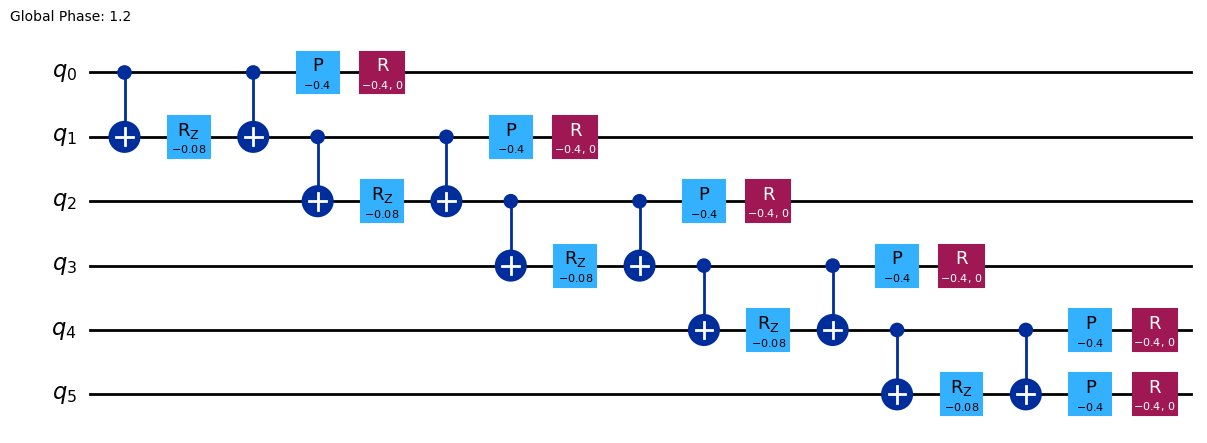

In [ ]:
H = get_hamiltonian(L=6, J=0.2, h=1.0)
print(f"Hamiltonian: {H}")
final_time = 10
num_timesteps = 50

dt = final_time / num_timesteps
trotter_step_first_order = PauliEvolutionGate(H, dt, synthesis=LieTrotter())

# We create an empty circuit
circuit = QuantumCircuit(H.num_qubits)
circuit.append(trotter_step_first_order, range(H.num_qubits))
circuit = circuit.decompose(reps=2)

print(
    f"""
Trotter step with Lie-Trotter
-----------------------------

                  Depth: {circuit.depth()}
             Gate count: {len(circuit)}
    Nonlocal gate count: {circuit.num_nonlocal_gates()}
         Gate breakdown: {", ".join([f"{k.upper()}: {v}" for k, v in circuit.count_ops().items()])}
"""
)

circuit.draw("mpl")

<h4 style="color:green; font-weight:bold; font-family:'Times New Roman';">
Second-order Trotterization (Suzuki-Trotterization)</h4>


Trotter step with Suzuki Trotter (2nd order)
--------------------------------------------

                  Depth: 34
             Gate count: 53
    Nonlocal gate count: 20
         Gate breakdown: CX: 20, P: 12, R: 11, RZ: 10




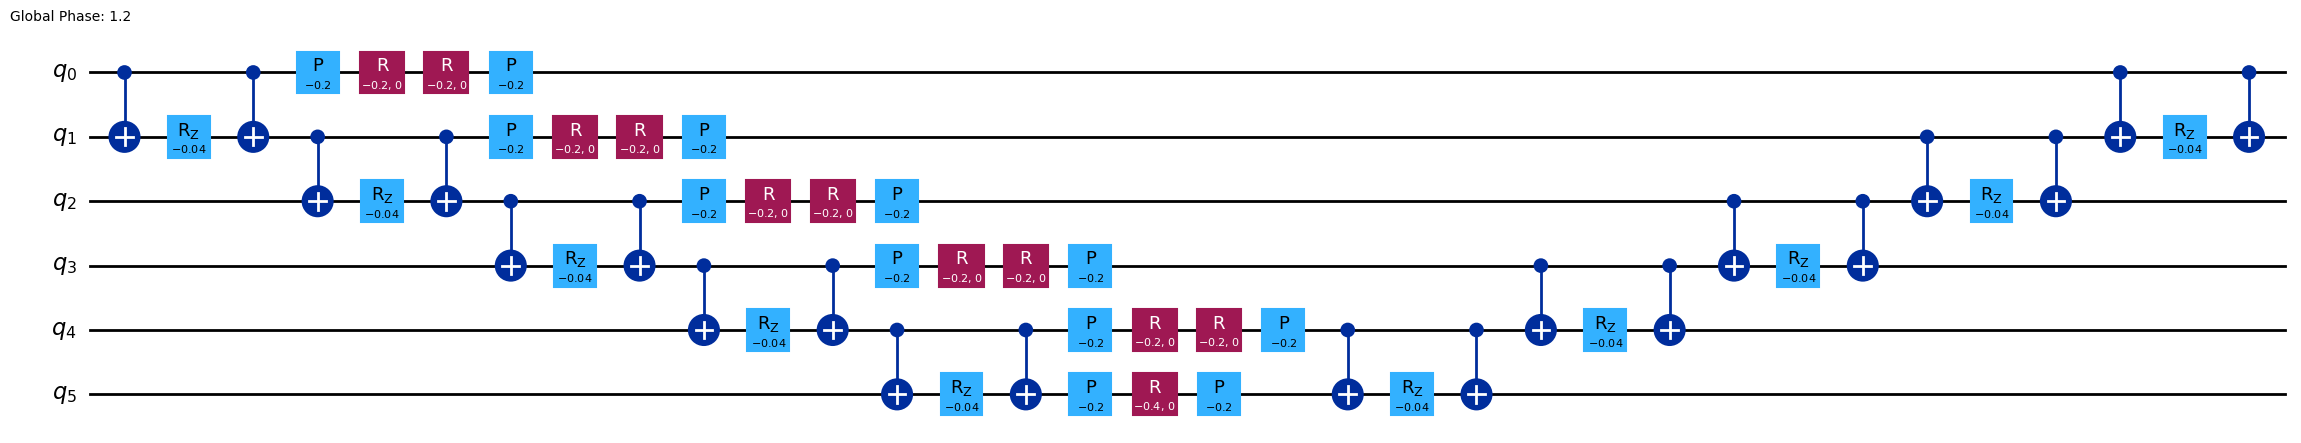

In [ ]:
second_order_formula = SuzukiTrotter(order=2)
trotter_step_second_order = PauliEvolutionGate(H, dt, synthesis=second_order_formula)
circuit = QuantumCircuit(H.num_qubits)
circuit.append(trotter_step_second_order, range(H.num_qubits))
circuit = circuit.decompose(reps=2)

print(
    f"""
Trotter step with Suzuki Trotter (2nd order)
--------------------------------------------

                  Depth: {circuit.depth()}
             Gate count: {len(circuit)}
    Nonlocal gate count: {circuit.num_nonlocal_gates()}
         Gate breakdown: {", ".join([f"{k.upper()}: {v}" for k, v in circuit.count_ops().items()])}

"""
)

circuit.draw("mpl", fold=-1)

In [ ]:
from version_table import print_table
print_table()